<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <h1>Proyecto Final - Procesamiento de Lenguaje Natural</h1>
    <h2>Deteccion de riesgo aduanero por posible subvaluacion</h2>
    <h3>NLP (texto de mercancia) + variables historicas</h3>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Pipeline que combina descripcion textual + variables historicas para detectar riesgo de subvaluacion.<br>
</div>


## 0. Referenciar clases y librerías

In [38]:
# Recarga automatica de los .py propios al editarlos (sin reiniciar el kernel)
%load_ext autoreload
%autoreload 2

import os, sys, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Clase de limpieza de texto (NLPTextCleaning.py)
sys.path.append(os.path.abspath('.'))
from NLPTextCleaning import NLPTextCleaningPipeline

# Clase de Acceso a los datos (SQLDataAccess.py)
sys.path.append(os.path.abspath('.'))
from SQLDataAccess import SQLDataAccess

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Configuración de columnas a usar
Listar los nombres de columnas.

In [39]:
CFG = {
    # --- columnas ---
    'col_hts':      'clave_fraccion',
    'col_desc':     'descripcion_ped',        # texto de la mercancia
    'col_precio':   'precio_unitario',
    'col_pais':     'clave_pais',
    'col_proveedor':'clave_proveedor',
    'col_tasa':     'advalorem',
    'col_fecha':    'fecha_pago',

    # --- objetivo NLP ---
    'hts_digitos':  6,             # 6 = subpartida HS; 8/10 = fraccion completa
    'test_size':    0.3

}

## 1. Cargar dataset de declaraciones aduaneras

In [40]:
# Prueba de la clase de acceso a datos (SQLDataAccess.py)

conn = SQLDataAccess.desde_json('db_config.json')

conn.probar_conexion()        
conn.listar_tablas()          # DataFrame con las tablas/vistas de la base de datos

Conexión OK -> 192.168.92.187/CkTrading (backend=pyodbc)


,TABLE_SCHEMA,TABLE_NAME,TABLE_TYPE
0,dbo,acce,BASE TABLE
1,dbo,aduasecc,BASE TABLE
2,dbo,agen,BASE TABLE
3,dbo,alma,BASE TABLE
4,dbo,aniosrep,BASE TABLE
...,...,...,...
146,dbo,vCalculoIVAIEPSAxlSNRound,VIEW
147,dbo,vCargosGlobales,VIEW
148,dbo,vent,BASE TABLE
149,dbo,ventmate,BASE TABLE


In [42]:
# La consulta SQL vive en db_config.json (seccion "consultas") -> se llama por nombre
df = conn.consultar_sql('impo_aduanas')

print(f"Filas: {df.shape[0]:,} y Columnas: {df.shape[1]}")
df.head()

Filas: 153,708 y Columnas: 7


,clave_fraccion,descripcion_ped,precio_unitario,clave_pais,clave_proveedor,advalorem,fecha_pago
0,87082922,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,1263.386667,MEX,8904,5.0,2010-05-17
1,87082922,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,1271.276667,MEX,8904,5.0,2010-05-17
2,87082922,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,1700.377677,MEX,8904,5.0,2010-05-17
3,87082922,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,1270.249333,MEX,8904,5.0,2010-05-17
4,87082922,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,1270.250000,MEX,8904,5.0,2010-05-17


## 2. Limpiar y preprocesar texto
Usamos la clase propia `NLPTextCleaningPipeline`. El texto HS esta en **español** -> `idioma='spanish'`.

In [43]:
limpiador = NLPTextCleaningPipeline(idioma='spanish', metodo_stem='snowball')

# Realizar la limpieza de texto en la columna 'descripción'

def limpiar_texto(t):
    if not isinstance(t, str):
        return ''
    return ' '.join(limpiador.preprocesar(t, metodo_final='lematizacion'))

df['desc_limpia'] = df[CFG['col_desc']].apply(limpiar_texto)
df[[CFG['col_desc'], 'desc_limpia']].head()

,descripcion_ped,desc_limpia
0,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,tablero instrumentos uso automotriz
1,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,tablero instrumentos uso automotriz
2,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,tablero instrumentos uso automotriz
3,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,tablero instrumentos uso automotriz
4,TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ,tablero instrumentos uso automotriz


## 3. Separación de datos Train / Test
Para la tener listos los datos de entrenamiento y test hacemos lo siguiente:
- Se define los digitos a utilizar para las categorias (fracciones). Se decide a 6 para mejor efectividad.
- Se quitan las fracciones que hayan quedado vacias despues de la limpieza
- Se utilizan las fracciones que tengan más de 5 ejemplos para que se evalue correctamente.

In [44]:
SEED = 42

# La fraccion arancelaria es la ETIQUETA (clasificacion multiclase).
# Trabajamos a nivel subpartida HS: primeros CFG['hts_digitos'] digitos.
fr = df[CFG['col_hts']].astype(str).str.strip().str.zfill(8)   # min 8 digitos (TIGIE)
df['hts'] = fr.str[:CFG['hts_digitos']]
TARGET = 'hts'

# Quitar filas cuyo texto quedo vacio tras la limpieza
df = df[df['desc_limpia'].str.strip() != ''].copy()

# Filtrar clases con muy pocos ejemplos (no se pueden aprender ni evaluar)
MIN_POR_CLASE = 5
conteos = df[TARGET].value_counts()
clases_validas = conteos[conteos >= MIN_POR_CLASE].index
antes = len(df)
df = df[df[TARGET].isin(clases_validas)].copy()
print(f"Clases ({CFG['hts_digitos']} digitos) con >= {MIN_POR_CLASE} ejemplos: {df[TARGET].nunique():,}")
print(f"Filas: {antes:,} -> {len(df):,}")

# Separacion estratificada: misma proporcion de cada clase en train y test
X = df['desc_limpia']
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CFG['test_size'], stratify=y, random_state=SEED)
print('Train:', X_train.shape[0], '| Test:', X_test.shape[0])

Clases (6 digitos) con >= 5 ejemplos: 71
Filas: 153,708 -> 153,661
Train: 107562 | Test: 46099


## 4. Creación de Pipelines
El Pipeline queda: Texto limpio -> TF-IDF -> Regresion Logistica.

In [45]:
# Pipeline: TF-IDF / Regresion Logistica
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)),      # min_df=3 decartamos téminos con menos de 3 documentos, sublinear_tf=True evita palabras repetidas dominen
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', solver='saga', max_iter=1000, n_jobs=-1, random_state=SEED)), # class_weight='balanced' porque hay fracciones con muchos regisros y otros con pocos
])
pipe

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## 5. Entrenar el modelo
Usaremos la variable historica descripción para el entrenamiento.

In [46]:
import time

# Entrenamiento: aprende la relacion descripcion limpia -> subpartida HS
t0 = time.time()
pipe.fit(X_train, y_train)
print(f"Entrenado en {time.time() - t0:.1f} s")
print("Terminos en el vocabulario TF-IDF:", len(pipe.named_steps['tfidf'].vocabulary_))
print("Clases aprendidas:", len(pipe.named_steps['clf'].classes_))

Entrenado en 651.7 s
Terminos en el vocabulario TF-IDF: 764
Clases aprendidas: 71


c:\Users\x\.conda\envs\nlp_curso_2026\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 6. Evaluacion del modelo


In [47]:
from sklearn.metrics import (accuracy_score, top_k_accuracy_score,
                             f1_score, classification_report)

clases = pipe.named_steps['clf'].classes_
y_pred = pipe.predict(X_test)
proba  = pipe.predict_proba(X_test)     # matriz (n_test x n_clases) para el top-k

# Metricas globales
acc  = accuracy_score(y_test, y_pred)
top3 = top_k_accuracy_score(y_test, proba, k=3, labels=clases)
top5 = top_k_accuracy_score(y_test, proba, k=5, labels=clases)


print(f"Accuracy (top-1): {acc:.3f}")
print(f"Top-3 accuracy:   {top3:.3f}   <- la fraccion correcta esta entre las 3 sugeridas")
print(f"Top-5 accuracy:   {top5:.3f}")

# Detalle para las 15 subpartidas mas frecuentes en test
print("\n--- Reporte de las 15 clases mas frecuentes ---")
top_clases = y_test.value_counts().head(15).index.tolist()
print(classification_report(y_test, y_pred, labels=top_clases, zero_division=0))

Accuracy (top-1): 0.918
Top-3 accuracy:   0.963   <- la fraccion correcta esta entre las 3 sugeridas
Top-5 accuracy:   0.974

--- Reporte de las 15 clases mas frecuentes ---
              precision    recall  f1-score   support

      870829       1.00      0.93      0.96     27064
      870892       1.00      0.99      0.99      6723
      870891       1.00      0.82      0.90      2617
      841520       1.00      1.00      1.00      1932
      841459       0.69      1.00      0.82      1075
      392690       0.74      0.35      0.48      1066
      854430       1.00      0.94      0.97       887
      840991       1.00      1.00      1.00       845
      853650       1.00      0.99      0.99       608
      732690       0.34      0.67      0.46       323
      854442       0.87      1.00      0.93       321
      400912       1.00      0.87      0.93       309
      841950       1.00      0.94      0.97       261
      852721       1.00      1.00      1.00       242
      852692   

## 7. Umbral de confianza (auto-sugerencia vs. revisión humana)
La probabilidad del top-1 se usa como **confianza**. Si supera un umbral, el sistema sugiere la fracción de forma automática; si no, se envía a **revisión humana**. Buscamos el punto que maximiza la cobertura manteniendo una precisión alta en lo automático.


Umbral elegido para precision >= 97%: 0.91
  -> 88.9% se auto-sugiere, 11.1% va a revision humana


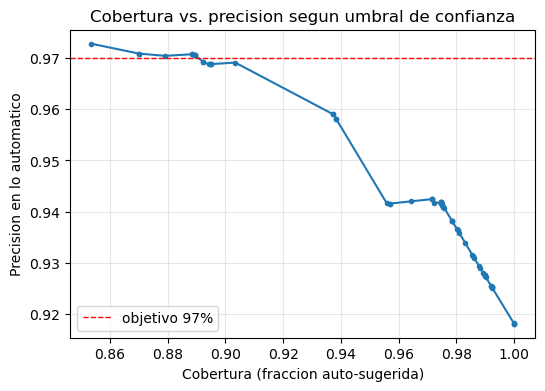

In [ ]:
# Confianza = probabilidad de la clase top-1
conf    = proba.max(axis=1)
acierto = (y_pred == y_test.values)

# Elegir el umbral mas bajo que alcanza una precision objetivo en lo automatico
PREC_OBJETIVO = 0.97
ts = np.linspace(0.30, 0.99, 70)
candidatos = [t for t in ts if acierto[conf >= t].mean() >= PREC_OBJETIVO and (conf >= t).any()]
UMBRAL = min(candidatos) if candidatos else 0.97
cob = (conf >= UMBRAL).mean()
print(f"\nUmbral elegido para precision >= {PREC_OBJETIVO:.0%}: {UMBRAL:.2f}")
print(f"  -> {cob:.1%} se auto-sugiere, {1 - cob:.1%} va a revision humana")

# Curva cobertura vs. precision
cobs = [(conf >= t).mean() for t in ts]
accs = [acierto[conf >= t].mean() if (conf >= t).any() else np.nan for t in ts]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(cobs, accs, marker='.')
ax.axhline(PREC_OBJETIVO, color='red', ls='--', lw=1, label=f'objetivo {PREC_OBJETIVO:.0%}')
ax.set_xlabel('Cobertura (fraccion auto-sugerida)')
ax.set_ylabel('Precision en lo automatico')
ax.set_title('Cobertura vs. precision segun umbral de confianza')
ax.legend(); ax.grid(alpha=.3)
plt.show()

## 8. Observaciones de respuesta
Genera los "motivos" del riesgo para la revision humana.

In [50]:
tfidf = pipe.named_steps['tfidf']
clf   = pipe.named_steps['clf']
vocab = np.array(tfidf.get_feature_names_out())

def explicar(descripcion, k=3, n_terminos=6):
    #Dada una descripcion -> top-k fracciones, motivos y decision.
    limpio = limpiar_texto(descripcion)
    x = tfidf.transform([limpio])                 # 1 x n_terminos (disperso)
    p = clf.predict_proba(x)[0]
    orden = np.argsort(p)[::-1][:k]
    top = [(clf.classes_[i], p[i]) for i in orden]

    # Terminos del texto que mas empujaron hacia la fraccion top-1
    c_idx = orden[0]
    contrib = x.multiply(clf.coef_[c_idx]).tocoo()    
    pares = sorted(zip(contrib.col, contrib.data), key=lambda t: t[1], reverse=True)
    terminos = [vocab[col] for col, val in pares[:n_terminos] if val > 0]

    decision = 'AUTO-SUGERIDA' if top[0][1] >= UMBRAL else 'REVISION HUMANA'
    return {'texto_limpio': limpio, 'top': top, 'terminos': terminos, 'decision': decision}

def mostrar(descripcion):
    r = explicar(descripcion)
    print(f"Descripcion : {descripcion}")
    print(f"Texto limpio: {r['texto_limpio']}")
    print(f"Decision    : {r['decision']}  (umbral {UMBRAL:.2f})")
    print("Top fracciones (subpartida HS):")
    for frac, prob in r['top']:
        print(f"   {frac}  ->  {prob:6.1%}")
    print("Motivos (terminos influyentes):", ", ".join(r['terminos']) or "(ninguno)")

# Descripción Ejemplo
descripcion = "VENTILADOR AUTOMOTRIZ"
mostrar(descripcion)

Descripcion : VENTILADOR AUTOMOTRIZ
Texto limpio: ventilador automotriz
Decision    : AUTO-SUGERIDA  (umbral 0.91)
Top fracciones (subpartida HS):
   841590  ->   93.7%
   853710  ->    2.3%
   853669  ->    1.4%
Motivos (terminos influyentes): ventilador automotriz, ventilador, automotriz


## 9. Demo en Gradio
Formulario con los campos de una importación y se obtendrá -> riesgo, probabilidad y motivos.

In [51]:
import gradio as gr

def predecir_ui(descripcion):
    if not descripcion or not descripcion.strip():
        return "Escribe una descripcion de la mercancia."
    r = explicar(descripcion)
    color = '🟢' if r['decision'] == 'AUTO-SUGERIDA' else '🟡'
    lineas = [f"### {color} {r['decision']}  (umbral {UMBRAL:.2f})",
              "**Fracciones sugeridas (subpartida HS, 6 digitos):**"]
    for i, (frac, prob) in enumerate(r['top'], 1):
        lineas.append(f"{i}. `{frac}`  —  {prob:.1%}")
    lineas += ["",
               f"**Motivos:** {', '.join(r['terminos']) or '(ninguno)'}",
               f"_Texto procesado:_ {r['texto_limpio']}"]
    return "\n".join(lineas)

demo = gr.Interface(
    fn=predecir_ui,
    inputs=gr.Textbox(lines=3, label="Descripcion de la mercancia",
                      placeholder="Ej. TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ"),
    outputs=gr.Markdown(label="Resultado"),
    title="Clasificador de fraccion arancelaria (HS6)",
    description="Dada la descripcion de la mercancia, sugiere la subpartida HS mas probable y los motivos.",
    examples=[["TABLERO DE INSTRUMENTOS PARA USO AUTOMOTRIZ"],
              ["TORNILLOS DE ACERO INOXIDABLE"],
              ["ELEVADOR"],
              ["MAQUINA DISPENSADORA CON ACCESORIOS"]],
)
demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


## 10. Conclusiones

**Objetivo alcanzado.** Se construyó un pipeline de NLP que, a partir de la descripción textual de una mercancía, sugiere su **subpartida arancelaria (HS, 6 dígitos)**. El flujo completo es: consulta SQL parametrizada → limpieza/lematización → TF-IDF (1-2 gramas) → Regresión Logística multiclase → umbral de confianza → motivos explicables → demo en Gradio.

**Resultados (conjunto de prueba):**

| Métrica | Valor |
|---|---|
| Accuracy (top-1) | **0.918** |
| Top-3 accuracy | **0.963** |
| Top-5 accuracy | **0.974** |
| F1 *weighted* | 0.941 |
| F1 *macro* | 0.693 |

- El **top-3 de 96.3%** es el resultado más relevante para el caso de uso: usado como apoyo al clasificador humano, la fracción correcta casi siempre está entre las tres sugeridas.
- La brecha entre **F1 weighted (0.94) y macro (0.69)** indica que el modelo es muy sólido en las subpartidas frecuentes, pero sufre en las **clases poco representadas o de descripción genérica** (p. ej. `392690` artículos de plástico, `732690` artículos de acero), donde el texto no aporta suficiente señal discriminante.

**Estrategia operativa (umbral de confianza).** En lugar de aceptar toda predicción, se usa la probabilidad del top-1 para decidir entre **auto-sugerencia** y **revisión humana**. Esto permite fijar una precisión objetivo alta en lo automático y enviar a revisión solo los casos dudosos, que coinciden con las clases problemáticas.

**Interpretabilidad.** Cada sugerencia se acompaña de los **términos que más influyeron** (TF-IDF × coeficiente de la clase), lo que da trazabilidad al revisor y facilita auditar el modelo.

**Consideraciones y limitaciones:**
- La calidad depende fuertemente de la **descripción capturada**: textos vagos o abreviados degradan la predicción.
- Se filtraron fracciones con menos de 5 ejemplos; esas mercancías raras quedan fuera del alcance del modelo actual.
- El nivel de 6 dígitos (subpartida HS) simplifica el problema; la **fracción completa (8/10 dígitos)** tiene muchas más clases y será más difícil.

**Próximos pasos:**
- Probar a **8 dígitos** (`CFG['hts_digitos'] = 8`) y comparar la caída de desempeño.
- Reforzar clases débiles: más datos, *embeddings* (p. ej. modelos tipo BERT en español) o un enfoque **jerárquico** (capítulo → partida → subpartida).
- **Segunda fase del proyecto:** sobre esta base, incorporar `precio_unitario`, `clave_pais`, `clave_proveedor` y `advalorem` para la **detección de riesgo de subvaluación / fraude**.